In [ ]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import altair as alt
alt.data_transformers.disable_max_rows()
alt.display.renderers.enable('svg')
import matplotlib.pyplot as plt

import act
import act.discovery, act.io

import metpy.calc, metpy.constants
from metpy.units import units
import glob
from tqdm import tqdm
from sublimpy import utils
import datetime as dt

In [ ]:
# for SAIL data queries
username = os.getenv("ARM_USERNAME")
token = os.getenv("ARM_TOKEN")
start_date = "20230409"
end_date = "20230419"
data_dir = "/Users/elischwat/Development/data/sublimationofsnow/"

from datetime import datetime, timedelta

def generate_date_range(start_date, end_date):
    # Parse the input dates
    start = datetime.strptime(start_date, '%Y%m%d')
    end = datetime.strptime(end_date, '%Y%m%d')
    
    # Generate the list of dates
    date_list = []
    current_date = start
    while current_date <= end:
        date_list.append(current_date.strftime('%Y%m%d'))
        current_date += timedelta(days=1)
    
    return date_list
dates = generate_date_range(start_date, end_date)
dates

# Observations

## SOS towers

In [ ]:
sos_df = pd.read_parquet("../paper1/process_slow_data/tidy_df_20221101_20230619_planar_fit_multiplane_q7_flags9000_pf10.parquet")
sos_df_localtime = utils.modify_df_timezone(
    sos_df,
    'UTC',
    'US/Mountain'
)


In [ ]:
src = sos_df_localtime[sos_df_localtime.time.dt.date == dt.date(2023,4,18)]
src = src.query("measurement == 'wind speed'").query("tower == 'c'")

In [ ]:
alt.Chart(
    src.set_index('time').sort_index().loc['20230418 1500': '20230418 2259'].reset_index()
).mark_line().encode(
    alt.X('value:Q').title('Wind speed (m/s)'),
    alt.Y('height:Q').title('Height (m)'),
    alt.Color('minutes(time):O'),
    alt.Facet('hours(time):O', columns=4),
    order='height'
).properties(width=150, height=150)

In [ ]:
sos_relevant_netcdf_files = sorted(glob.glob('/Users/elischwat/Development/data/sublimationofsnow/sosqc/sos_isfs_qc_geo_tiltcor_5min_v20241227/*.nc'))[159:170]

In [ ]:
# OPEN NETCDFS so we can use 5 minute skewnesss
datasets = []
# for april 9 - 19
sos_relevant_netcdf_files = sorted(glob.glob('/Users/elischwat/Development/data/sublimationofsnow/sosqc/sos_isfs_qc_geo_tiltcor_5min_v20241227/*.nc'))[159:170]
# for march 4 - 8
# sos_relevant_netcdf_files = sorted(glob.glob('/Users/elischwat/Development/data/sublimationofsnow/sosqc/sos_isfs_qc_geo_tiltcor_5min_v20241227/*.nc'))[123:128]
# for dec 21-22
# sos_relevant_netcdf_files = sorted(glob.glob('/Users/elischwat/Development/data/sublimationofsnow/sosqc/sos_isfs_qc_geo_tiltcor_5min_v20241227/*.nc'))[50:52]
for file in sos_relevant_netcdf_files:
    ds = xr.open_dataset(file)
    datasets.append(ds)

sos_ds = xr.concat(datasets, dim='time')

In [ ]:
days_list = [(pd.to_datetime(start_date) + dt.timedelta(days=i)).strftime('%Y-%m-%d') 
             for i in range((pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1)]

print(days_list)

In [ ]:
sos_ds_localtime = utils.modify_xarray_timezone(
        sos_ds,
        'UTC',
        'US/Mountain'
    )
for day in days_list:
    
    this_day_dataset = sos_ds_localtime.sel(time=slice(
        dt.datetime.strptime(day, '%Y-%m-%d'), 
        dt.datetime.strptime(day, '%Y-%m-%d') + dt.timedelta(days=1)
    ))
    this_day_dataset['w_w_w__3m_c'].plot(figsize=(10,3))
    this_day_dataset['w_w_w__10m_c'].plot(ax=plt.gca())
    this_day_dataset['w_w_w__20m_c'].plot(ax=plt.gca())
    plt.show()

## SAIL doppler lidar VS mode

In [ ]:
# Inputs
DLW_DATA_STREAM = 'gucdlprofwstats4newsM1.c1'
DLW_DATA_STREAM_FILEEXT = '.cdf'
DLW_OUTPUT_DIR = os.path.join(data_dir, DLW_DATA_STREAM)


In [ ]:
# file_list = act.discovery.download_arm_data(
#     username, token, DLW_DATA_STREAM, start_date, end_date, output = DLW_OUTPUT_DIR
#     )

In [ ]:
file_list = [f for f in glob.glob(os.path.join(data_dir, DLW_DATA_STREAM, '*.nc')) if '20230418' in f or '20230419' in f]

In [ ]:
dl_wstats = xr.open_mfdataset(file_list)
dl_wstats = utils.modify_xarray_timezone(
    dl_wstats,
    'UTC',
    'US/Mountain'
)

In [ ]:
dl_wstats.sel(height = slice(0,2000))['w'].plot(x = 'time', y='height', figsize=(10,4), cmap='RdYlBu')
plt.xlim('20230418 0000', '20230419 0000')
plt.ylim(0, 900)
plt.title('Vertical velocity variance from vertically-staring Doppler Lidar')

In [ ]:
dl_wmean_df = dl_wstats.sel(height = slice(0,2000))[['w', 'snr']].sel(time=slice('20230418 0000', '20230419 0000')).to_dataframe()
dl_wmean_df = dl_wmean_df.query("snr > 0.008")
dl_wmean_df = dl_wmean_df.reset_index()
def plot(src):
    base_chart = alt.Chart(
        src
    ).mark_line().encode(
        alt.X('mean(w):Q').scale(domain=[-1,1], clamp=True),
        alt.Y('height:Q'),
        alt.Color('hours(time):O').scale(scheme='rainbow'),
        order='height'
    )
    vertical_line = alt.Chart().mark_rule(color='black', strokeWidth=3).encode(
        x=alt.datum(0)  # Add a vertical line at x=0
    )
    horiz_line_600 = alt.Chart().mark_rule(color='red', strokeWidth=1).encode(
        y=alt.datum(600)  # Add a vertical line at x=0
    )
    horiz_line_900 = alt.Chart().mark_rule(color='red', strokeWidth=1).encode(
        y=alt.datum(900)  # Add a vertical line at x=0
    )
    return base_chart + vertical_line + horiz_line_600 + horiz_line_900
((
    plot(dl_wmean_df[dl_wmean_df.time.dt.hour.isin([0,1,2,3,4,5])]) |
    plot(dl_wmean_df[dl_wmean_df.time.dt.hour.isin([6,7,8,9,10,11])])
).resolve_scale(color='independent') & (
    plot(dl_wmean_df[dl_wmean_df.time.dt.hour.isin([12,13,14,15,16,17])]) |
    plot(dl_wmean_df[dl_wmean_df.time.dt.hour.isin([18,19,20,21,22,23])])   
).resolve_scale(color='independent')).resolve_scale(color='independent')

In [ ]:
src = dl_wmean_df.query("height < 900").set_index('time')
src.groupby(pd.Grouper(freq='30min'))['w'].mean().plot()
plt.axhline(0)
print(
    src['w'].mean()
)

In [ ]:
dl_wstats.sel(height = slice(0,2000))['w_variance'].plot(x = 'time', y='height', figsize=(10,4), vmin=0, vmax=20, cmap='gist_ncar')
# plt.xlim('20230418 0000', '20230419 0000')
plt.title('Vertical velocity variance from vertically-staring Doppler Lidar')

In [ ]:
dl_wstats.sel(height = slice(0,2000))['w_skewness'].plot(x = 'time', y='height', figsize=(10,4), vmin=-2, vmax=2, cmap='RdYlBu')
# plt.xlim('20230418 0000', '20230419 0000')
plt.title('Vertical velocity skewness from vertically-staring Doppler Lidar')

## SAIL Radiosonde Data

In [ ]:
# Define the data code and date range
sonde_data_code = 'gucsondewnpnM1.b1'
# Download the data


In [ ]:
# files = act.discovery.download_arm_data(
#     username,
#     token,
#     sonde_data_code,
#     start_date,
#     end_date,
#     output = os.path.join(data_dir, sonde_data_code)
# )
# files = sorted(files)

In [ ]:
files = pd.Series([start_date,end_date]).apply(
    lambda d: glob.glob(os.path.join(data_dir, sonde_data_code, f"*{d}*.cdf"))
)
files = sorted(list((files).explode()))
files

In [ ]:
files = pd.Series([start_date,end_date]).apply(
    lambda d: glob.glob(os.path.join(data_dir, sonde_data_code, f"*{d}*.cdf"))
)
files = sorted(list((files).explode()))
files
sondes_ds = xr.open_mfdataset(files)
sondes_df = sondes_ds.to_dataframe().reset_index()
sondes_df = utils.modify_df_timezone(sondes_df, 'UTC', 'US/Mountain')
sondes_df['date'] = sondes_df.time.dt.date.astype(str)
sondes_df['hour'] = sondes_df.time.dt.hour
sondes_df['timeofday'] = (sondes_df['hour'] < 12).apply(lambda is_morning: 'Morning' if is_morning else 'Afternoon')

## Gothic Sail Tower data

In [ ]:
# # Define the data codes for meteorological and turbulence data
# data_codes = [
#     'gucmetM1.b1',  # Example data code for meteorological data
#     'guc30ecorM1.b1'  # Example data code for turbulence data
# ]

# # Loop through each data code and download the data
# data_dict = {}
# for data_code in data_codes:
#     files = act.discovery.download_arm_data(
#         username,  # Replace with your ARM username
#         token,        # Replace with your ARM token
#         data_code,
#         start_date,
#         end_date,
#         output = os.path.join(data_dir, data_code)
#     )
#     print(files)
#     # Load the data into an ACT object and append to the list
#     ds = act.io.read_arm_netcdf(files)
#     data_dict[data_code] = ds

# gothic_met = data_dict[data_codes[0]]
# gothic_ec = data_dict[data_codes[1]]

In [ ]:

files = pd.Series(dates).apply(
    lambda d: glob.glob(os.path.join(data_dir, 'guc30ecorM1.b1', f"*{d}*.cdf"))
)
files = sorted(list((files).explode()))
sail_ecor_ds = xr.open_mfdataset(files)
sail_ecor_df = sail_ecor_ds.to_dataframe().reset_index()
sail_ecor_df_localtime = utils.modify_df_timezone(sail_ecor_df, 'UTC', 'US/Mountain')
sail_ecor_df_localtime = sail_ecor_df_localtime.query("bound == 0") ##???
sail_ecor_df_localtime

In [ ]:

files = pd.Series(dates).apply(
    lambda d: glob.glob(os.path.join(data_dir, 'gucmetM1.b1', f"*{d}*.cdf"))
)
files = sorted(list((files).explode()))
sail_met_ds = xr.open_mfdataset(files)
sail_met_df = sail_met_ds.to_dataframe().reset_index()
sail_met_df_localtime = utils.modify_df_timezone(sail_met_df, 'UTC', 'US/Mountain')
sail_met_df_localtime = sail_met_df_localtime.query("bound == 0") ##???
sail_met_df_localtime

## Avery Picnic SPLASH Tower data

In [ ]:
files = pd.Series(dates).apply(
    lambda d: glob.glob(os.path.join(data_dir, "asfs/ASFS-50_Level2_SPLASH2021-2023/", f"sledseb.asfs50.level2.0.10min.{d}*.nc"))
).explode()
files = sorted(files)
files

In [ ]:
splash_asfs_ds = xr.open_mfdataset(files)
splash_asfs_df = splash_asfs_ds.to_dataframe().reset_index()
splash_asfs_df_localtime = utils.modify_df_timezone(splash_asfs_df, 'UTC', 'US/Mountain')
splash_asfs_df_localtime

## Doppler Lidar Vertical Wind Profiles

In [ ]:
# Inputs
DLWProf_DATA_STREAM = 'gucdlprofwind4newsM1.c1'
DLWProf_DATA_STREAM_FILEEXT = '.cdf'
DLWProf_OUTPUT_DIR = os.path.join(data_dir, DLWProf_DATA_STREAM)
# file_list = act.discovery.download_arm_data(
#             username, token, DLWProf_DATA_STREAM, start_date, end_date, output = DLWProf_OUTPUT_DIR)
# dl_wprof = xr.open_mfdataset(file_list)

In [ ]:
file_list = list(pd.Series(dates).apply(lambda d: glob.glob(os.path.join(DLWProf_OUTPUT_DIR, f"*{d}*.nc"))).explode())
dl_wprof = xr.open_mfdataset(file_list)

In [ ]:
dl_wprof_df = dl_wprof.to_dataframe().reset_index()
dl_wprof_df['time'] = dl_wprof_df['time'].dt.round('15min')
dl_wprof_df_localtime = utils.modify_df_timezone(dl_wprof_df, 'UTC', 'US/Mountain')
dl_wprof_df_localtime = dl_wprof_df_localtime.set_index('time').reset_index()

# Create Figure (options) for Paper

Plot lines, hours by panel

In [ ]:
dl_wprof_localtime = utils.modify_xarray_timezone(dl_wprof, 'UTC', 'US/Mountain')
dl_wprof_localtime['wind_direction'].sel(
    time=slice('20230418', '20230418'),
    height = slice(0,2000)
).T.plot.contourf(levels=20, cmap='hsv')

In [ ]:
src = dl_wprof_df_localtime.query("height < 1600").set_index('time').loc[
    dates[-2]
    # dates[0]
].reset_index()
# src = src[src.time.dt.hour % 4 == 0]
src = src[src.time.dt.hour.isin([4, 9, 14, 20])]
src['hour'] = src.time.dt.hour
src = src[['hour', 'height', 'u', 'v']].groupby(['hour', 'height']).mean()
src['wind_direction'] = np.rad2deg(np.arctan2(
    - src['u'],
    - src['v'],
))
src['wind_direction'] = src['wind_direction'].apply(lambda d: d if d > 0 else d + 360)
src['wind_speed'] = np.sqrt(src['u']**2 + src['v']**2)
src = src.reset_index()

In [ ]:
alt.layer(
    (alt.Chart().mark_circle().encode(
        alt.X('wind_direction:Q').scale(domain=[0,360]).axis(values=[0,90,180,270,360],
                                                             titleColor ='#1f77b4', labelColor ='#1f77b4').title(
            'Wind dir.'
        ),
        alt.Y('height:Q'),        
        order='height'
    )
     + 
    alt.Chart().mark_circle(color='#fc8d62').encode(
        alt.X('wind_speed:Q').scale(domain=[0,20]).axis(titleColor='#fc8d62', labelColor='#fc8d62'),
        alt.Y('height:Q'),        
        order='height'
    )
    ).resolve_scale(x='independent'),
    alt.Chart().transform_calculate(y = '960').mark_rule(color='red').encode(y='y:Q'),
    alt.Chart().transform_calculate(y = '510').mark_rule(color='red').encode(y='y:Q'),
    data = src
).properties(
        width=125,
        height=125
).facet(
    'hour',
    # columns=3,
    spacing=0,
    # 'hours(time):O',
    # columns=4,
    
    # header=alt.Header()
).resolve_scale(y='shared', x='independent')

In [ ]:
def dl_winds_daily_plot(src):
    src['hour'] = src.time.dt.hour
    src['height_bin'] = pd.cut(
        src.height,
        np.arange(0,2100,100)
    ).apply(lambda rang: 0.5*(rang.left + rang.right))
    src = src[['time', 'hour', 'height_bin', 'u', 'v']].set_index('time').groupby(
        [pd.Grouper(freq='60min'), 'height_bin']
    ).mean()
    src['wind_direction'] = np.rad2deg(np.arctan2(
        - src['u'],
        - src['v'],
    ))
    src['wind_direction'] = src['wind_direction'].apply(lambda d: d if d > 0 else d + 360)
    src['bearing'] = src['wind_direction'] - 180
    src['bearing'] = src['bearing'].apply(lambda d: d if d > 0 else d + 360)
    src['wind_speed'] = np.sqrt(src['u']**2 + src['v']**2)
    src = src.reset_index()

    return alt.Chart(src).mark_point(filled=True).encode(
        alt.X('time:T'),
        alt.Y('height_bin:Q'),
        alt.Angle('median(bearing)'),
        alt.Size('wind_speed:O').bin(step=2).scale(range=[100,400]),
        alt.Color('wind_speed:O').bin(step=2).scale(scheme='turbo'),
        alt.Shape('wind_speed:O').bin(step=2).scale(
            range=['circle', 'arrow',  'arrow', 'arrow',  'arrow', 'arrow',  'arrow', 'arrow',  'arrow', 'arrow',  'arrow']
        )
    ).properties(width=400, height=200)
dl_winds_daily_plot(dl_wprof_df_localtime.query("height < 1600").set_index('time').loc[dates[0]].reset_index()) |\
dl_winds_daily_plot(dl_wprof_df_localtime.query("height < 1600").set_index('time').loc[dates[-2]].reset_index())

In [ ]:
# gather wind measuremnts from three sites, calculate hourly means, then wind directions and wind speeds
avp_hourly_dir = splash_asfs_df_localtime[['time', 'wspd_u_mean', 'wspd_v_mean']].set_index('time').resample('60min').mean()
got_hourly_dir = sail_ecor_df_localtime[['time', 'mean_u', 'mean_v']].set_index('time').resample('60min').mean()
kps_hourly_dir = sos_df_localtime[sos_df_localtime.variable.isin(['u_3m_c', 'v_3m_c'])].pivot_table(
    index='time',
    columns='variable',
    values='value'
).resample('60min').mean()

avp_hourly_dir['wind_direction'] = np.rad2deg(np.arctan2(
    - avp_hourly_dir['wspd_u_mean'],
    - avp_hourly_dir['wspd_v_mean'],
))
got_hourly_dir['wind_direction'] = - np.rad2deg(np.arctan2( #IDK WHY BUT THE SAIL MATH IS WEIRD
    - got_hourly_dir['mean_v'],
    - got_hourly_dir['mean_u'],
))

kps_hourly_dir['wind_direction'] = np.rad2deg(np.arctan2(
    - kps_hourly_dir['u_3m_c'],
    - kps_hourly_dir['v_3m_c'],
))

avp_hourly_dir['wind_speed'] = np.sqrt(avp_hourly_dir['wspd_u_mean']**2 + avp_hourly_dir['wspd_v_mean']**2)
got_hourly_dir['wind_speed'] = np.sqrt(got_hourly_dir['mean_v']**2 + got_hourly_dir['mean_u']**2)
kps_hourly_dir['wind_speed'] = np.sqrt(kps_hourly_dir['u_3m_c']**2 + kps_hourly_dir['v_3m_c']**2)

surf_winds_df = pd.concat([
    avp_hourly_dir.assign(site = 'avp')[['site', 'wind_speed', 'wind_direction']],
    got_hourly_dir.assign(site = 'got')[['site', 'wind_speed', 'wind_direction']],
    kps_hourly_dir.assign(site = 'kps')[['site', 'wind_speed', 'wind_direction']],
])

In [ ]:
surf_winds_df['wind_direction'] = surf_winds_df['wind_direction'] - 180
surf_winds_df['wind_direction'] = surf_winds_df['wind_direction'].apply(lambda d: d if d > 0 else d + 360)

In [ ]:
def surface_winds_daily_plot(src):
    return alt.Chart(
        src
    ).mark_point(filled=True).encode(
        alt.X('time:T').axis(format='%H:%M'),
        alt.Y('site:N'),
        alt.Angle('wind_direction:Q'),
        alt.Size('wind_speed:O').bin(step=2).scale(range=[100,400]),
        alt.Color('wind_speed:O').bin(step=2).scale(scheme='turbo'),
        alt.Shape('wind_speed:O').bin(step=2).scale(
            range=['circle', 'arrow',  'arrow', 'arrow',  'arrow', 'arrow',  'arrow', 'arrow',  'arrow', 'arrow',  'arrow']
        )
    ).properties(width=400)

In [ ]:
((
    dl_winds_daily_plot(dl_wprof_df_localtime.query("height < 1600").set_index('time').loc[dates[0]].reset_index()) |\
    dl_winds_daily_plot(dl_wprof_df_localtime.query("height < 1600").set_index('time').loc[dates[-2]].reset_index())
) & (
    surface_winds_daily_plot(surf_winds_df.loc[dates[0]].reset_index()) |\
    surface_winds_daily_plot(surf_winds_df.loc[dates[-2]].reset_index())
)).resolve_scale(color='shared', x='shared', size='shared')

In [ ]:
wind_direction_df = pd.DataFrame(
    sos_df_localtime.query("variable == 'dir_3m_c'").set_index('time').sort_index().loc[start_date: end_date].value.rename('SOS 3m')
).join(
    dl_wprof_df_localtime.query("height > 1000").query("height < 1600").groupby('time')['wind_direction'].median().rename('DL, 1km')
).join(
    sail_ecor_df_localtime.set_index('time')['wind_dir'].rename('SAIL 3m')
).join(
    splash_asfs_df_localtime.set_index('time')['wdir_vec_mean'].drop_duplicates().resample('30min').median().rename('SPLASH 5m')
)


In [ ]:
temp_df = pd.concat([
    sos_df_localtime.query("variable == 'T_3m_c'").set_index('time').reset_index().assign(key = 'SOS 3m').set_index('time')[[
        'key',
        'value'
    ]],
    splash_asfs_df_localtime[['time', 'temp']].set_index('time').resample('30min').mean().assign(key = 'SPLASH 5m').rename(columns={'temp':'value'}),
    sail_met_df_localtime[['time','temp_mean']].set_index('time').resample('30min').mean().assign(key = 'SAIL 3m').rename(columns={'temp_mean': 'value'})
])

In [ ]:
def wind_dir_chart(date):
    return alt.Chart(
        wind_direction_df.loc[date].reset_index()
    ).transform_fold(
        wind_direction_df.columns
    ).mark_circle().encode(
        alt.X('time:T').axis(labels=False, tickCount='hour', format='%H:%M').title(''),
        alt.Y('value:Q').axis(values=[0,90,180,270,360]).scale(domain=[0,360]),
        # .scale(domain=[0,360]).axis(values=[0,90,180,270,360]),
        alt.Color('key:N')
    ).properties(width=200, height=100)

def wind_spd_chart(date):
    return alt.Chart(
        wind_speed_df.loc[date].reset_index()
    ).transform_fold(
        wind_speed_df.columns
    ).mark_line().encode(
        alt.X('time:T').axis(labels=False, tickCount='hour', format='%H:%M').title(''),
        alt.Y('value:Q'),
        alt.Color('key:N')
    ).properties(width=200, height=100)

def rsw_in_chart(date):
    return alt.Chart(
        sos_df_localtime.query("variable == 'Rsw_in_9m_d'").set_index('time').loc[date].reset_index().assign(key = 'SOS 3m')
    ).mark_line().encode(
        alt.X('time:T').axis(labels=False, tickCount='hour', format='%H:%M').title(''),
        alt.Y('value:Q'),
        alt.Color('key:N')
    ).properties(width=200, height=100)

def T_chart(date):
    return alt.Chart(
        temp_df.loc[date].reset_index()
    ).mark_line().encode(
        alt.X('time:T').axis(tickCount='hour', format='%H:%M'),
        alt.Y('value:Q'),
        alt.Color('key:N')
    ).properties(width=200, height=100)

In [ ]:
wind_dir_chart('20230409') | wind_dir_chart('20230418')

In [ ]:
(
    (wind_dir_chart('20230409') | wind_dir_chart('20230418')).resolve_scale(y='shared', )
    & 
    (wind_spd_chart('20230409') | wind_spd_chart('20230418')).resolve_scale(y='shared', )
    &
    (rsw_in_chart('20230409') | rsw_in_chart('20230418')).resolve_scale(y='shared', )
    & 
    (T_chart('20230409') | T_chart('20230418')).resolve_scale(y='shared', )
).resolve_scale(color='shared', x='shared')

# Create Figure for Paper

In [ ]:
surf_scaling_sos_df = sos_df_localtime[sos_df_localtime.variable.isin([
    'tke_3m_c',
    'spd_3m_c'
])].pivot_table(index='time', columns='variable', values='value').loc[start_date: end_date]
surf_scaling_sos_df = surf_scaling_sos_df.rename(columns = {
    'spd_3m_c': 'wind_speed',
    'tke_3m_c': 'TKE'
})
surf_scaling_sos_df

In [ ]:
surf_scaling_sail_df = sail_ecor_df_localtime.set_index('time')[['wind_spd']].join(
    0.5*(sail_ecor_df.set_index('time')[['var_u', 'var_v', 'var_w']]).sum(axis=1).rename('tke')
).drop_duplicates()
surf_scaling_sail_df = surf_scaling_sail_df.rename(columns = {
    'wind_spd': 'wind_speed',
    'tke': 'TKE'
})
surf_scaling_sail_df

In [ ]:
splash_shrink = splash_asfs_df_localtime[[
    'wspd_vec_mean',
    'time',
    'sigU',
    'sigV',
    'sigW',
]].drop_duplicates()
surf_scaling_splash_df = splash_shrink.set_index('time')[['wspd_vec_mean']].join(
    (splash_shrink.set_index('time')[['sigU', 'sigV', 'sigW']]**2).sum(axis=1).rename('tke')
)
surf_scaling_splash_df = surf_scaling_splash_df.rename(columns = {
    'wspd_vec_mean': 'wind_speed',
    'tke': 'TKE'
})
surf_scaling_splash_df = surf_scaling_splash_df.resample('30min').mean()

In [ ]:
combo_surf_scaling_df = pd.concat([
        surf_scaling_sos_df.assign(site='sos'),
        surf_scaling_sail_df.assign(site='sail'),
        surf_scaling_splash_df.assign(site='splash')
    ]).reset_index()
combo_surf_scaling_df

In [ ]:
alt.Chart(
    combo_surf_scaling_df[
        (combo_surf_scaling_df.time.dt.date == dt.date(2023, 4, 9))
        |
        (combo_surf_scaling_df.time.dt.date == dt.date(2023, 4, 18))
    ]
).mark_line().encode(
    alt.X('time:T'),
    alt.Y('wind_speed:Q'),
    alt.Color('site:N'),
    alt.Facet('date(time):O')
).resolve_scale(x='independent').properties(height=150) &\
alt.Chart(
    combo_surf_scaling_df[
        (combo_surf_scaling_df.time.dt.date == dt.date(2023, 4, 9))
        |
        (combo_surf_scaling_df.time.dt.date == dt.date(2023, 4, 18))
    ]
).mark_line().encode(
    alt.X('time:T'),
    alt.Y('TKE:Q'),
    alt.Color('site:N'),
    alt.Facet('date(time):O')
).resolve_scale(x='independent').properties(height=150)

In [ ]:
src = combo_surf_scaling_df[
        (combo_surf_scaling_df.time.dt.date == dt.date(2023, 4, 9))
        |
        (combo_surf_scaling_df.time.dt.date == dt.date(2023, 4, 18))
    ]
src['Vtke'] = src['TKE']**0.5
alt.Chart(
    src
).mark_point(size=50).encode(
    alt.X('wind_speed:Q'),
    alt.Y('Vtke:Q'),
    alt.Color('date(time):N'),
    alt.Shape('site:N')
)

Time series of wind speed stuff

In [ ]:
fig, axes = plt.subplots(2,1,figsize=(7.5,6), sharex=True)

# Top Panel
sos_wind_speeds = sos_df_localtime.query("variable == 'spd_3m_c'").set_index('time').sort_index().loc[start_date: end_date]

dl_wprof_df_localtime.query("height > 1000").query("height < 2000").groupby('time')['wind_speed'].median().plot(ax=axes[0], label='Synoptic (lidar, 1-1.5 km)')
sos_wind_speeds.value.plot(ax=axes[0], linestyle=':', label='Surface (tower, 3m)')
axes[0].axhline(20, color='grey')
axes[0].set_ylabel('Wind speed, (m/s)')
sondes_dots_df = sondes_df.query("alt > 4000").query("alt < 5000").groupby(['date', 'timeofday']).median().reset_index()
axes[0].scatter( sondes_dots_df.time.values, sondes_dots_df.wspd.values, marker='^', label='Synoptic (radiosonde, 1-1.5 km)', facecolors='none', edgecolors='black')
axes[0].legend()
axes[0].set_ylim(0,25)

# Bottom Panel
sos_wind_directions = sos_df_localtime.query("variable == 'dir_3m_c'").set_index('time').sort_index().loc[start_date: end_date]

dl_wprof_df_localtime.query("height > 1000").query("height < 1500").groupby('time')['wind_direction'].median().plot(ax=axes[1], label='Synoptic (lidar, 1-1.5 km)')
sos_wind_directions.value.plot(ax=axes[1], linestyle=':', label='Surface (tower, 3m)')
# Calculate median wind direction from radiosondes
sondes_dots_df = sondes_df.query("alt > 4000").query("alt < 5000").groupby(['date', 'timeofday']).median().reset_index()
axes[1].scatter( sondes_dots_df.time.values, sondes_dots_df.deg.values, marker='^', label='Synoptic (radiosonde, 1-1.5 km)', facecolors='none', edgecolors='black')
axes[1].set_ylabel('Wind direction (˚)')
axes[1].set_yticks([0, 90, 180, 270, 360])
axes[1].legend()
axes[1].fill_between(x= sos_wind_directions.index.values, y1=185, y2=265, color='grey', alpha=0.25)
axes[1].fill_between(x= sos_wind_directions.index.values, y1=275, y2=355, color='darkgrey', alpha=0.15)
# axes[1].text(x='2023-03-08T06:30:00.000000000', y=305, s='Cross-valley', fontweight='bold', color='darkgrey', fontsize=16)  # BEGIN:
# axes[1].text(x='2023-03-08T06:30:00.000000000', y=215, s='Along-valley', fontweight='bold', color='darkgrey', fontsize=16)  # END:
# plt.xlim('20221221 0000', '202212222 0000')

In [ ]:
src = dl_wprof_df_localtime.query("height > 1000").query("height < 2000").dropna().groupby('time')[['wind_direction', 'wind_speed']].median().reset_index()
src['day_of_month'] = src['time'].dt.day
src['time_of_day'] = src['time'].apply(lambda dt: dt.replace(day=1))
alt.Chart(
    src
).mark_circle().encode(
    alt.X('time_of_day:T').axis(title=None),
    alt.Y('wind_direction:Q').scale(domain=[180,360], clamp=True),
    alt.Color('wind_speed:Q'),
    alt.Size('wind_speed:Q'),
    alt.Facet('day_of_month', columns=5)
).properties(width=200, height = 200).resolve_scale(
    x='shared'
) 

In [ ]:
plt.figure(figsize=(15,6))
utils.modify_xarray_timezone(sos_ds['spd_3m_c'], 'UTC', 'US/Mountain').sel(time = slice(start_date, end_date)).plot()

utils.modify_xarray_timezone(sos_ds['Rsw_in_9m_d'], 'UTC', 'US/Mountain').sel(time = slice(start_date, end_date)).plot(
    ax=plt.twinx(), color='tab:orange'
)

In [ ]:
modeled_fluxes_df = pd.read_parquet("/Users/elischwat/Development/sublimationofsnow/analysis/paper1_old/coare_model_results.parquet")
modeled_fluxes_df.config.unique()

In [ ]:
modeled_fluxes_df = modeled_fluxes_df.query("config == 'Tsurf_c e_sat_alduchov 0.0001 3m'")
modeled_fluxes_df.head()

In [ ]:
modeled_fluxes_df_localtime = utils.modify_df_timezone(
    modeled_fluxes_df.reset_index(), 'UTC', 'US/Mountain'
).set_index('time').sort_index()

In [ ]:
from metpy.units import units
def w_tc_to_watts(values):
    specific_heat_capacity_air = 1.0005 * units('kilojoules/(K*kg)')
    air_density = 1 * units("kg/m^3")
    sensible_heat_flux_meas_units = values * units("K*m/s")
    return (sensible_heat_flux_meas_units * specific_heat_capacity_air * air_density).to("W/m^2").magnitude
def w_h2o_to_watts(values):
    latent_heat_of_vaporization = 2838 * units("J/g")
    latent_heat_flux_meas_units = values * units("g/(m^2 * s)")
    return (latent_heat_flux_meas_units * latent_heat_of_vaporization).to("W/m^2").magnitude

In [ ]:
alt.Chart(
    sos_df_localtime.query("measurement == 'w'").query("tower == 'c'").set_index('time').sort_index().loc[start_date: end_date].reset_index()
).mark_line().encode(
    alt.X('time:T'),
    alt.Y('value:Q'),
    alt.Color('height:O').scale(scheme='rainbow')
).properties(width=1200)

In [ ]:
plt.figure(figsize=(15,3))

w_tc_measured_series = sos_df_localtime.query("variable == 'w_tc__3m_c'").set_index('time').sort_index()[['value']]
w_tc_measured_series.value = w_tc_to_watts(w_tc_measured_series.value.values)

w_h2o_measured_series = sos_df_localtime.query("variable == 'w_h2o__3m_c_raw'").set_index('time').sort_index()[['value']]
w_h2o_measured_series.value = w_h2o_to_watts(w_h2o_measured_series.value.values)

w_h2o_measured_series['value'].loc[start_date: end_date].plot(label='Hₗ, measured', color='tab:blue')
modeled_fluxes_df_localtime['hlb'].loc[start_date: end_date].plot(label='Hₗ, modeled', color='tab:blue', linestyle='--')

w_tc_measured_series['value'].loc[start_date: end_date].plot(label='Hₛ, measured', color='tab:orange')
modeled_fluxes_df_localtime['hsb'].loc[start_date: end_date].plot(label='Hₛ, modeled', color='tab:orange', linestyle='--')
plt.ylabel("Heat flux (W m$^{-2}$)")
plt.legend()

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(7.5,6), sharey=True)

w_tc_measured_series = sos_df_localtime.query("variable == 'w_tc__3m_c'").set_index('time').sort_index()[['value']]
w_tc_measured_series.value = w_tc_to_watts(w_tc_measured_series.value.values)

w_h2o_measured_series = sos_df_localtime.query("variable == 'w_h2o__3m_c_raw'").set_index('time').sort_index()[['value']]
w_h2o_measured_series.value = w_h2o_to_watts(w_h2o_measured_series.value.values)

w_h2o_measured_series['value'].loc[start_date: end_date].loc['20230409'].plot(label='Hₗ, measured', color='tab:blue', ax=axes[0])
modeled_fluxes_df_localtime['hlb'].loc[start_date: end_date].loc['20230409'].plot(label='Hₗ, modeled', color='tab:blue', linestyle='--', ax=axes[0])
w_tc_measured_series['value'].loc[start_date: end_date].loc['20230409'].plot(label='Hₛ, measured', color='tab:orange', ax=axes[0])
modeled_fluxes_df_localtime['hsb'].loc[start_date: end_date].loc['20230409'].plot(label='Hₛ, modeled', color='tab:orange', linestyle='--', ax=axes[0])

w_h2o_measured_series['value'].loc[start_date: end_date].loc['20230418'].plot(label='Hₗ, measured', color='tab:blue', ax=axes[1])
modeled_fluxes_df_localtime['hlb'].loc[start_date: end_date].loc['20230418'].plot(label='Hₗ, modeled', color='tab:blue', linestyle='--', ax=axes[1])
w_tc_measured_series['value'].loc[start_date: end_date].loc['20230418'].plot(label='Hₛ, measured', color='tab:orange', ax=axes[1])
modeled_fluxes_df_localtime['hsb'].loc[start_date: end_date].loc['20230418'].plot(label='Hₛ, modeled', color='tab:orange', linestyle='--', ax=axes[1])

for ax in axes:
    ax.set_ylabel("Heat flux (W m$^{-2}$)")
plt.legend()

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(7.5,6), sharey=True)

w_tc_measured_series = sos_df_localtime.query("variable == 'w_tc__3m_c'").set_index('time').sort_index()[['value']]
w_tc_measured_series.value = w_tc_to_watts(w_tc_measured_series.value.values)

w_h2o_measured_series = sos_df_localtime.query("variable == 'w_h2o__3m_c_raw'").set_index('time').sort_index()[['value']]
w_h2o_measured_series.value = w_h2o_to_watts(w_h2o_measured_series.value.values)

w_h2o_measured_series['value'].loc[start_date: end_date].loc['20230409'].plot(label='Hₗ, measured', color='tab:blue', ax=axes[0])
modeled_fluxes_df_localtime['hlb'].loc[start_date: end_date].loc['20230409'].plot(label='Hₗ, modeled', color='tab:blue', linestyle='--', ax=axes[0])
# w_tc_measured_series['value'].loc[start_date: end_date].loc['20230409'].plot(label='Hₛ, measured', color='tab:orange', ax=axes[0])
# modeled_fluxes_df_localtime['hsb'].loc[start_date: end_date].loc['20230409'].plot(label='Hₛ, modeled', color='tab:orange', linestyle='--', ax=axes[0])

w_h2o_measured_series['value'].loc[start_date: end_date].loc['20230418'].plot(label='Hₗ, measured', color='tab:blue', ax=axes[1])
modeled_fluxes_df_localtime['hlb'].loc[start_date: end_date].loc['20230418'].plot(label='Hₗ, modeled', color='tab:blue', linestyle='--', ax=axes[1])
# w_tc_measured_series['value'].loc[start_date: end_date].loc['20230418'].plot(label='Hₛ, measured', color='tab:orange', ax=axes[1])
# modeled_fluxes_df_localtime['hsb'].loc[start_date: end_date].loc['20230418'].plot(label='Hₛ, modeled', color='tab:orange', linestyle='--', ax=axes[1])

for ax in axes:
    ax.set_ylabel("Heat flux (W m$^{-2}$)")
plt.legend()
plt.savefig('models.svg')

In [ ]:
from functools import reduce

In [ ]:
meas_mod_df = pd.concat([
    pd.DataFrame(w_h2o_measured_series['value'].loc[start_date: end_date].loc['20230409'].rename('measured')).join(
        modeled_fluxes_df_localtime['hlb'].loc[start_date: end_date].loc['20230409'].rename('modeled')
    ).assign(variable = 'Hl'),
    pd.DataFrame(w_tc_measured_series['value'].loc[start_date: end_date].loc['20230409'].rename('measured')).join(
        modeled_fluxes_df_localtime['hsb'].loc[start_date: end_date].loc['20230409'].rename('modeled'),
    ).assign(variable = 'Hs'),
    pd.DataFrame(w_h2o_measured_series['value'].loc[start_date: end_date].loc['20230418'].rename('measured')).join(
        modeled_fluxes_df_localtime['hlb'].loc[start_date: end_date].loc['20230418'].rename('modeled')
    ).assign(variable = 'Hl'),
    pd.DataFrame(w_tc_measured_series['value'].loc[start_date: end_date].loc['20230418'].rename('measured')).join(
        modeled_fluxes_df_localtime['hsb'].loc[start_date: end_date].loc['20230418'].rename('modeled'),
    ).assign(variable = 'Hs')
])
meas_mod_df

In [ ]:
alt.Chart(meas_mod_df.reset_index()).transform_fold(
    ['measured', 'modeled']
).mark_line().encode(
    alt.X('time:T'),
    alt.Y('value:Q'),
    alt.StrokeDash('key:N'),
    alt.Color('variable:N').scale(range=['black', 'grey']),
    alt.Row('date(time)')
).resolve_scale(x='independent').properties(height=150)

In [ ]:
print('20230409 Hl')
print('r^2\t\t' + str((meas_mod_df.loc['20230409'].query("variable == 'Hl'")[['measured', 'modeled']].corr()**2).measured.modeled))
print('Mean bias\t' + str((meas_mod_df.loc['20230409'].query("variable == 'Hl'")['modeled'] - meas_mod_df.loc['20230409'].query("variable == 'Hl'")['measured']).mean()))
print()
print('20230409 Hs')
print('r^2\t\t' + str((meas_mod_df.loc['20230409'].query("variable == 'Hs'")[['measured', 'modeled']].corr()**2).measured.modeled))
print('Mean bias\t' + str((meas_mod_df.loc['20230409'].query("variable == 'Hs'")['modeled'] - meas_mod_df.loc['20230409'].query("variable == 'Hs'")['measured']).mean()))
print()
print()
print('20230418 Hl')
print('r^2\t\t' + str((meas_mod_df.loc['20230418'].query("variable == 'Hl'")[['measured', 'modeled']].corr()**2).measured.modeled))
print('Mean bias\t' + str((meas_mod_df.loc['20230418'].query("variable == 'Hl'")['modeled'] - meas_mod_df.loc['20230418'].query("variable == 'Hl'")['measured']).mean()))
print()
print('20230418 Hs')
print('r^2\t\t' + str((meas_mod_df.loc['20230418'].query("variable == 'Hs'")[['measured', 'modeled']].corr()**2).measured.modeled))
print('Mean bias\t' + str((meas_mod_df.loc['20230418'].query("variable == 'Hs'")['modeled'] - meas_mod_df.loc['20230418'].query("variable == 'Hs'")['measured']).mean()))

# MODEL NON LOCAL ADVECTIVE FLUX

$$\overline{w'\phi'} \approx - K \frac{\partial \overline{\phi}}{\partial z} + \frac{L}{T V} w (\phi_{up} - \overline{\phi})$$

Pull in tropoe scans to test using them for $\phi_up$

In [ ]:
tropoe_ds = xr.open_mfdataset([
    "/Users/elischwat/Development/data/sublimationofsnow/tropoe_from_bianca/gucM1tropoeAERI.raso_ctrl.20230418.001005.nc",
    "/Users/elischwat/Development/data/sublimationofsnow/tropoe_from_bianca/gucM1tropoeAERI.raso_ctrl.20230419.001005.nc",
])
tropoe_df = tropoe_ds[['theta', 'waterVapor', 'pressure', 'temperature']].to_dataframe().reset_index()
tropoe_df = utils.modify_df_timezone(tropoe_df, 'UTC', 'US/Mountain')
tropoe_df['height'] = tropoe_df['height']*1000
dry_air_density = metpy.calc.density(
    pressure = tropoe_df['pressure'].values * units("millibars"), 
    temperature = tropoe_df['temperature'].values * units('degC'),
    mixing_ratio=0
)
abs_humidity = tropoe_df['waterVapor']*units('g/kg') * dry_air_density
tropoe_df['abs_humidity'] = abs_humidity

Get $L$ and $T$

In [ ]:
# term 1 is from above
L = 250 * units("meters")
T = 200 * units("seconds")

Get $V$

In [ ]:
# GET 30min 1--1.5 SYNOPTIC WIND SPEED for ENTIRE DAY
dl_wprof_df = dl_wprof['wind_speed'].resample(time='30min').mean().to_dataframe().reset_index()
dl_wprof_df = dl_wprof_df[(dl_wprof_df.height >= 1000) & (dl_wprof_df.height <= 1500)]
dl_wprof_df = dl_wprof_df.groupby('time')[['wind_speed']].mean()
V_df = dl_wprof_df.loc['20230418']

Get $w$

In [ ]:
# GET 30min w_20m_c from SOS site
w_df = sos_df.query("variable == 'w_20m_c'")[['time','value']].set_index('time').loc['20230418']

Get $\phi_{up}$

In [ ]:
##################
### from sondes
##################

# GET 30min 1--1.5km abs. humidity from radiosondes (apply 0430 value to 0000-1200, 1630 value to 1200-2400)
sonde_df_20230418 = xr.open_mfdataset(glob.glob(os.path.join(data_dir, sonde_data_code, f"*20230418*.cdf"))).to_dataframe().reset_index()
sonde_df_20230418 = utils.modify_df_timezone(sonde_df_20230418, 'UTC', 'US/Mountain')
sonde_df_20230418['date'] = sonde_df_20230418.time.dt.date.astype(str)
sonde_df_20230418['hour'] = sonde_df_20230418.time.dt.hour
sonde_df_20230418['timeofday'] = (sonde_df_20230418['hour'] < 12).apply(lambda is_morning: 'Morning' if is_morning else 'Afternoon')
h2o_mixing_ratio = metpy.calc.mixing_ratio_from_relative_humidity(
    sonde_df_20230418.pres.values * units("millibars"),
    sonde_df_20230418.tdry.values * units('degC'),
    sonde_df_20230418.rh.values * units("percent")
)
dry_air_density = metpy.calc.density(
    sonde_df_20230418.pres.values * units("millibars"),
    sonde_df_20230418.tdry.values * units('degC'),
    0
)
sonde_df_20230418['abs_humidity'] = (h2o_mixing_ratio * dry_air_density).to(units('g/m^3'))
sonde_df_20230418['height'] = sonde_df_20230418.alt - 2891
sonde_df_20230418 = sonde_df_20230418[
    (sonde_df_20230418.height >= 1000)
    &
    (sonde_df_20230418.height <= 1500)
]
sonde_df_20230418 = sonde_df_20230418.groupby('timeofday')['abs_humidity'].mean()

phi_up_df = w_df.copy()
phi_up_df = pd.concat([
    phi_up_df.loc['20230418 0000': '20230418 1130'].assign(abs_humidity = sonde_df_20230418['Morning']),
    phi_up_df.loc['20230418 1200': '20230418 2330'].assign(abs_humidity = sonde_df_20230418['Afternoon']),
])[['abs_humidity']]

##################
### from tropoe
##################
phi_up_tropoe_df = tropoe_df[tropoe_df.height >= 1000][tropoe_df.height <= 1500]
phi_up_tropoe_df = phi_up_tropoe_df.groupby('time')[['abs_humidity']].mean()
phi_up_tropoe_df = phi_up_tropoe_df.groupby(pd.Grouper(freq='30min')).mean()
phi_up_tropoe_df = phi_up_tropoe_df.loc['20230418']

Get $\phi$

In [ ]:
# phi = # GET 30min 3 meter abs. humidity from SOS data
# GET 30min w_20m_c from SOS site
phi_df = (
    sos_df.query("variable == 'mixingratio_2m_c'")[['time','value']].set_index('time').loc['20230418']
    *
    sos_df.query("variable == 'dryairdensity_2m_c'")[['time','value']].set_index('time').loc['20230418']
)*1000

Combine all to calculate non-local transport

$$ \frac{L}{T V} w (\phi_{up} - \overline{\phi})$$

In [ ]:
# L, T, V_df, w_df, phi_up_df, phi_df
nonlocal_transport_df = V_df.rename(columns={'wind_speed': 'V'}).join(
    w_df['value'].rename('w')
).join(
    phi_up_df['abs_humidity'].rename('phi_up')
).join(
    phi_df['value'].rename('phi')
).join(
    phi_up_tropoe_df['abs_humidity'].rename('phi_up_tropoe')
)
nonlocal_transport_df.insert(0, 'T', T.magnitude)
nonlocal_transport_df.insert(0, 'L', L.magnitude)

In [ ]:
nonlocal_transport_df['w'] = nonlocal_transport_df['w'].apply(
    lambda w: 0 if w > 0 else w
)

In [ ]:
# nonlocal_transport_results = ((
#     (nonlocal_transport_df['L'].values*units('meters')) / (
#         nonlocal_transport_df['T'].values*units('seconds')
#         * nonlocal_transport_df['V'].values*units('meters/second')
#     )
# ) * (nonlocal_transport_df['w'].values*units('meters/second')) * (
#     (nonlocal_transport_df['phi_up_tropoe'].values*units('g/m^3'))
#     - (nonlocal_transport_df['phi'].values*units('g/m^3'))
# ))
# nonlocal_transport_results

nonlocal_transport_results = (
    0.1 * (nonlocal_transport_df['w'].values*units('meters/second')) * (
    (nonlocal_transport_df['phi_up_tropoe'].values*units('g/m^3'))
    - (nonlocal_transport_df['phi'].values*units('g/m^3'))
))
nonlocal_transport_results

In [ ]:
modeled_fluxes_df_localtime

In [ ]:
nonlocal_and_local_transport = modeled_fluxes_df_localtime.loc['20230418'][['hlb']].rename(columns={'hlb': 'modeled (local)'})
nonlocal_and_local_transport['modeled (nonlocal)'] = w_h2o_to_watts(nonlocal_transport_results.magnitude)
nonlocal_and_local_transport['modeled (local and nonlocal)'] = nonlocal_and_local_transport.sum(axis=1)
nonlocal_and_local_transport = nonlocal_and_local_transport.join(
    sos_df_localtime.query("variable == 'w_h2o__3m_c_raw'").set_index('time').sort_index()['value'].loc['20230418'].rename('hlb_measured')
)
nonlocal_and_local_transport['measured'] = w_h2o_to_watts(nonlocal_and_local_transport['hlb_measured'].values)
# nonlocal_and_local_transport['hlb'].plot(label='Local')
# nonlocal_and_local_transport['local and nonlocal'].plot(label='Local and nonlocal')
# nonlocal_and_local_transport['hlb_measured'].plot(label='Measured', color='k')
nonlocal_and_local_transport

alt.Chart(
    nonlocal_and_local_transport.reset_index()
).transform_fold([
    'modeled (local)', 'modeled (local and nonlocal)', 'measured'
]).mark_line(color='black').encode(
    alt.X('time:T').title(''),
    alt.Y('value:Q').title('Latent heat flux (W m⁻²)'),
    alt.StrokeDash('key:N').scale(
        domain = ['measured', 'modeled (local)', 'modeled (local and nonlocal)'],
        range = [[1,0], [4,2], [1,1]]
    ),
    alt.Color()
).properties(height=150)

In [ ]:
nonlocal_and_local_transport = modeled_fluxes_df_localtime.loc['20230418'][['hlb_gperm2s']]
nonlocal_and_local_transport['nonlocal'] = nonlocal_transport_results
nonlocal_and_local_transport['hlb_gperm2s'].cumsum().plot(label='Local')
nonlocal_and_local_transport.sum(axis=1).cumsum().plot(label='Local and nonlocal')
sos_df_localtime.query("variable == 'w_h2o__3m_c_raw'").set_index('time').sort_index()['value'].loc['20230418'].cumsum().plot(label='Measured', color='k')
plt.legend()

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(8,4), sharex=True, sharey=True)
axes[0].scatter(
    sos_df_localtime.query("variable == 'w_h2o__3m_c_raw'").set_index('time').sort_index()['value'].loc['20230418'].values,
    nonlocal_and_local_transport['hlb_gperm2s'].values
)
axes[1].scatter(
    sos_df_localtime.query("variable == 'w_h2o__3m_c_raw'").set_index('time').sort_index()['value'].loc['20230418'].values,
    nonlocal_and_local_transport.sum(axis=1).values
)
plt.xlim(0,0.06)
plt.ylim(0,0.06)
for ax in axes:
    ax.plot([0, 0.06], [0, 0.06], color='red', linestyle='--')  # One-to-one line for subplot 0

In [ ]:
# - K d \phi / dz

sos_df_localtime.query("variable == 'Tsurfmixingratio_c'").set_index('time')['value']
vel_scale = np.sqrt(sos_df_localtime.query("variable == 'tke_20m_c'").set_index('time')['value'])
L = 0.41*3
K = vel_scale*L
abs_hum_2m = (
    sos_df_localtime.query("variable == 'mixingratio_2m_c'").set_index('time')['value']
     * sos_df_localtime.query("variable == 'dryairdensity_2m_c'").set_index('time')['value']
)
abs_hum_0m = (
    sos_df_localtime.query("variable == 'Tsurfmixingratio_c'").set_index('time')['value']
     * sos_df_localtime.query("variable == 'Tsurfdryairdensity_c'").set_index('time')['value']
)
delta_phi_over_delta_z = (
    abs_hum_2m - abs_hum_0m
) / 2
local_mixing_flux = - K * delta_phi_over_delta_z

In [ ]:
# local_mixing_flux.loc['20230418'].plot(label='Local (basic)')
nonlocal_and_local_transport = modeled_fluxes_df_localtime.loc['20230418'][['hlb_gperm2s']]
nonlocal_and_local_transport['nonlocal'] = nonlocal_transport_results
nonlocal_and_local_transport['hlb_gperm2s'].plot(label='Local')
nonlocal_and_local_transport.sum(axis=1).plot(label='Local and nonlocal')
sos_df_localtime.query("variable == 'w_h2o__3m_c_raw'").set_index('time').sort_index()['value'].loc['20230418'].plot(label='Measured', color='k')
plt.legend()

In [ ]:
w_h2o_to_watts(0.15) / 8

In [ ]:
along_valley_wind_times = pd.read_csv('along_valley_wind_times.csv')
cross_valley_wind_times = pd.read_csv('cross_valley_wind_times.csv')
fast_wind_times = pd.read_csv('winds_ge10_times.csv')
slow_wind_times = pd.read_csv('winds_le10_times.csv')

In [ ]:
src = modeled_fluxes_df_localtime[['hlb', 'hsb', 'tau']].join(
    w_h2o_measured_series['value'].rename('hlb_measured')
).join(
    w_tc_measured_series['value'].rename('hsb_measured')
).join(
    (sos_df_localtime.query("variable == 'u*_3m_c'").set_index('time').sort_index()['value']**2).rename('tau_measured')
)
src = pd.concat([
    src[src.index.isin(along_valley_wind_times['0'])].assign(type='along'),
    src[src.index.isin(cross_valley_wind_times['0'])].assign(type='cross'),
])
src = pd.concat([
    src[src.index.isin(fast_wind_times['time'])].assign(speed='fast'),
    src[src.index.isin(slow_wind_times['time'])].assign(speed='slow'),
])
src.head(3)
src

In [ ]:
# scatter_chart = alt.Chart(src).mark_circle().encode(
#     alt.X('hlb_measured:Q').title('Measured').scale(clamp=True, domain=[-10,50]).bin(step=5),
#     alt.Y('median(hlb):Q').title('Modeled').scale(clamp=True, domain=[-10,50]),
#     # alt.Facet('speed:N'),
#     alt.Color('type:N')
# )
mean_chart = alt.Chart(src).mark_circle(size=100).encode(
    alt.X('hlb_measured:Q').title('Measured').scale(clamp=True, domain=[-10,50]).bin(step=5),
    alt.Y('mean(hlb):Q').title('Modeled').scale(clamp=True, domain=[-10,50]),
    # alt.Facet('speed:N'),
    alt.Color('type:N')
)

count_chart = alt.Chart(src).mark_text(fontSize=8).encode(
    alt.X('hlb_measured:Q').title('Measured').scale(clamp=True, domain=[-10,50]).bin(step=5),
    alt.Text('count():Q').title('Modeled'),
)

iqr_chart = alt.Chart(src).mark_line(size=5, opacity=0.4).encode(
    alt.X('hlb_measured:Q').title('Measured').scale(clamp=True, domain=[-10,50]).bin(step=5),
    alt.Y('q1(hlb):Q'),
    alt.Y2('q3(hlb):Q'),
    alt.Color('type:N')
)

# Create a DataFrame for the 1:1 line
line_data = pd.DataFrame({
    'x': [-10, 50],
    'y': [-10, 50]
})

# 1:1 line chart
line_chart = alt.Chart(line_data).mark_line(color='red').encode(
    alt.X('x:Q'),
    alt.Y('y:Q')
)

# Combine the scatter plot and the 1:1 line
((
    count_chart.transform_filter(alt.datum.speed == 'fast') 
    & mean_chart.transform_filter(alt.datum.speed == 'fast').transform_filter(alt.datum.hlb_measured <= 40) 
    + iqr_chart.transform_filter(alt.datum.hlb_measured <= 40)
    + line_chart
) | (
    count_chart.transform_filter(alt.datum.speed == 'slow')
    & mean_chart.transform_filter(alt.datum.speed == 'slow').transform_filter(alt.datum.hlb_measured <= 40) 
    + iqr_chart.transform_filter(alt.datum.hlb_measured <= 40) 
    + line_chart
)).properties(title='Latent heat fluxes')

In [ ]:
src.loc['20230418'].sort_index()[['hlb', 'hlb_measured']].plot()

In [ ]:
# scatter_chart = alt.Chart(src).mark_circle().encode(
#     alt.X('hsb_measured:Q').title('Measured').scale(clamp=True, domain=[-60,50]).bin(step=5),
#     alt.Y('median(hsb):Q').title('Modeled').scale(clamp=True, domain=[-60,50]),
#     # alt.Facet('speed:N'),
#     alt.Color('type:N')
# )
mean_chart = alt.Chart(src).mark_circle(size=100).encode(
    alt.X('hsb_measured:Q').title('Measured').scale(clamp=True, domain=[-60,50]).bin(step=5),
    alt.Y('mean(hsb):Q').title('Modeled').scale(clamp=True, domain=[-60,50]),
    # alt.Facet('speed:N'),
    alt.Color('type:N')
)

count_chart = alt.Chart(src).mark_text(fontSize=8).encode(
    alt.X('hsb_measured:Q').title('Measured').scale(clamp=True, domain=[-60,50]).bin(step=5),
    alt.Text('count():Q').title('Modeled'),
)

iqr_chart = alt.Chart(src).mark_line(size=5, opacity=0.4).encode(
    alt.X('hsb_measured:Q').title('Measured').scale(clamp=True, domain=[-60,50]).bin(step=5),
    alt.Y('q1(hsb):Q'),
    alt.Y2('q3(hsb):Q'),
    alt.Color('type:N')
)

# Create a DataFrame for the 1:1 line
line_data = pd.DataFrame({
    'x': [-60, 50],
    'y': [-60, 50]
})

# 1:1 line chart
line_chart = alt.Chart(line_data).mark_line(color='red').encode(
    alt.X('x:Q'),
    alt.Y('y:Q')
)

# Combine the scatter plot and the 1:1 line
((
    count_chart.transform_filter(alt.datum.speed == 'fast') 
    & mean_chart.transform_filter(alt.datum.speed == 'fast').transform_filter(alt.datum.hsb_measured <= 20).transform_filter(alt.datum.hsb_measured >= -60) 
    + iqr_chart.transform_filter(alt.datum.hsb_measured <= 20).transform_filter(alt.datum.hsb_measured >= -60)
    + line_chart
) | (
    count_chart.transform_filter(alt.datum.speed == 'slow')
    & mean_chart.transform_filter(alt.datum.speed == 'slow').transform_filter(alt.datum.hsb_measured <= 20).transform_filter(alt.datum.hsb_measured >= -60) 
    + iqr_chart.transform_filter(alt.datum.hsb_measured <= 20).transform_filter(alt.datum.hsb_measured >= -60) 
    + line_chart
)).properties(title='Sensible heat fluxes')

In [ ]:
# scatter_chart = alt.Chart(src).mark_circle().encode(
#     alt.X('tau_measured:Q').title('Measured').scale(clamp=True, domain=[0, 0.12]).bin(step=0.01),
#     alt.Y('median(tau):Q').title('Modeled').scale(clamp=True, domain=[0, 0.12]),
#     # alt.Facet('speed:N'),
#     alt.Color('type:N')
# )
mean_chart = alt.Chart(src).mark_circle(size=100).encode(
    alt.X('tau_measured:Q').title('Measured').scale(clamp=True, domain=[0, 0.12]).bin(step=0.01),
    alt.Y('mean(tau):Q').title('Modeled').scale(clamp=True, domain=[0, 0.12]),
    # alt.Facet('speed:N'),
    alt.Color('type:N')
)

count_chart = alt.Chart(src).mark_text(fontSize=8).encode(
    alt.X('tau_measured:Q').title('Measured').scale(clamp=True, domain=[0, 0.12]).bin(step=0.01),
    alt.Text('count():Q').title('Modeled'),
)

iqr_chart = alt.Chart(src).mark_line(size=5, opacity=0.4).encode(
    alt.X('tau_measured:Q').title('Measured').scale(clamp=True, domain=[0, 0.12]).bin(step=0.01),
    alt.Y('q1(tau):Q'),
    alt.Y2('q3(tau):Q'),
    alt.Color('type:N')
)

# Create a DataFrame for the 1:1 line
line_data = pd.DataFrame({
    'x': [0, 0.12],
    'y': [0, 0.12]
})

# 1:1 line chart
line_chart = alt.Chart(line_data).mark_line(color='red').encode(
    alt.X('x:Q'),
    alt.Y('y:Q')
)

# Combine the scatter plot and the 1:1 line
((
    count_chart.transform_filter(alt.datum.speed == 'fast').transform_filter(alt.datum.tau_measured < 0.12)
    & mean_chart.transform_filter(alt.datum.speed == 'fast').transform_filter(alt.datum.tau_measured < 0.12)
    + iqr_chart.transform_filter(alt.datum.tau_measured < 0.12)
    + line_chart
) | (
    count_chart.transform_filter(alt.datum.speed == 'slow').transform_filter(alt.datum.tau_measured < 0.12)
    & mean_chart.transform_filter(alt.datum.speed == 'slow').transform_filter(alt.datum.tau_measured < 0.12)
    + iqr_chart.transform_filter(alt.datum.tau_measured < 0.12)
    + line_chart
)).properties(title='Momentum fluxes')

In [ ]:
plt.figure(figsize=(15,6))

w_tc_measured_series = utils.modify_df_timezone(
    sos_df.query("variable == 'w_tc__3m_c'"), 'UTC', 'US/Mountain'
).set_index('time').sort_index()[['value']]
w_tc_measured_series.value = w_tc_to_watts(w_tc_measured_series.value.values)

w_tc_measured_series.loc['20230412': '20230419'].plot()

utils.modify_df_timezone(
    modeled_fluxes_df.reset_index(), 'UTC', 'US/Mountain'
).set_index('time').sort_index()['hsb'].loc['20230412': '20230419'].plot()

In [ ]:
from metpy.constants import dry_air_density_stp
dry_air_density_stp

measured_tau_df = sos_df.query("variable == 'u*_3m_c'")
measured_tau_df['value'] =  (dry_air_density_stp * (
    measured_tau_df.value.values * units("m/s")
)**2).magnitude

utils.modify_df_timezone(
    measured_tau_df, 'UTC', 'US/Mountain'
).set_index('time').sort_index().loc['20230412': '20230419'].value.plot()
utils.modify_df_timezone(
    modeled_fluxes_df.reset_index(), 'UTC', 'US/Mountain'
).set_index('time').sort_index()['tau'].loc['20230412': '20230419'].plot()

## Radiosonde

In [ ]:
from metpy.units import units

In [ ]:
sondes_df['tpot'] = metpy.calc.potential_temperature(
    sondes_df['pres'].values * units(sondes_ds['pres'].units),
    sondes_df['tdry'].values * units(sondes_ds['tdry'].units),
).magnitude

In [ ]:
alt.Chart(
    sondes_df.query('alt < 6000')[['rh', 'alt', 'date', 'timeofday']]
).mark_line().encode(
    alt.X('rh:Q'),
    alt.Y('alt:Q').scale(zero=False),
    alt.Facet('date:O', columns=5),
    alt.Color('timeofday:N'),
    order='alt'
).properties(width=200, height = 200)

In [ ]:
alt.Chart(
    sondes_df.query('alt < 6000')[['tpot', 'alt', 'date', 'timeofday']]
).mark_line().encode(
    alt.X('tpot:Q'),
    alt.Y('alt:Q').scale(zero=False),
    alt.Facet('date:O', columns=5),
    alt.Color('timeofday:N'),
    order='alt'
).properties(width=200, height = 200)

In [ ]:
utils.modify_xarray_timezone(
    sos_ds['T_3m_c'],
    'UTC',
    'US/Mountain'
).sel(time = slice('20230412 1000', '20230412 2000')).plot()
utils.modify_xarray_timezone(
    sos_ds['T_20m_c'],
    'UTC',
    'US/Mountain'
).sel(time = slice('20230412 1000', '20230412 2000')).plot()

utils.modify_xarray_timezone(
    sos_ds['w_w_w__20m_c'],
    'UTC',
    'US/Mountain'
).sel(time = slice('20230412 1000', '20230412 2000')).plot(ax=plt.twinx(), color='k')

In [ ]:
sos_df_localtime.query("variable == 'T_3m_c'").set_index('time').loc['20230412'].value.plot()
sos_df_localtime.query("variable == 'T_10m_c'").set_index('time').loc['20230412'].value.plot()
sos_df_localtime.query("variable == 'T_20m_c'").set_index('time').loc['20230412'].value.plot()

In [ ]:
sos_df_localtime.query("variable == 'temp_gradient_3m_c'").set_index('time').loc['20230412'].value.plot()
sos_df_localtime.query("variable == 'temp_gradient_10m_c'").set_index('time').loc['20230412'].value.plot()
sos_df_localtime.query("variable == 'temp_gradient_20m_c'").set_index('time').loc['20230412'].value.plot()
plt.axvline('20230412 1100')

# April 12 - vortex spectra?

In [ ]:
ds = xr.open_dataset("/Users/elischwat/Development/data/sublimationofsnow/gucdlrhiM1.b1/gucdlrhiM1.b1.20230412.191514.cdf")
# /Users/elischwat/Development/data/sublimationofsnow/gucdlrhiM1.b1/gucdlrhiM1.b1.20230412.191834.cdf
# /Users/elischwat/Development/data/sublimationofsnow/gucdlrhiM1.b1/gucdlrhiM1.b1.20230412.194513.cdf
# /Users/elischwat/Development/data/sublimationofsnow/gucdlrhiM1.b1/gucdlrhiM1.b1.20230412.194834.cdf

In [ ]:
ds['x'] = ds['range']*np.cos(np.deg2rad(ds['elevation']))
ds['z'] = ds['range']*np.sin(np.deg2rad(ds['elevation']))

ds = ds.set_coords(['x', 'z'])

plt.figure(figsize = (10,5))
plt.xlim(-2000, 2000)
plt.ylim(0, 2000)
ds.sel(range = slice(0,2000))['radial_velocity'].plot.contourf(x='x', y='z', cmap='gist_ncar', levels=50)

In [ ]:
df = ds.sel(range = slice(0,2000)).to_dataframe()[['x', 'z', 'radial_velocity']]
df

In [ ]:
from scipy.interpolate import griddata

# Extract x, z, and radial_velocity
x = df['x'].values
z = df['z'].values
radial_velocity = df['radial_velocity'].values

# Define a regular grid for x and z
x_grid = np.linspace(x.min(), x.max(), 4000)  # Adjust grid resolution as needed
z_grid = np.linspace(z.min(), z.max(), 2000)
x_mesh, z_mesh = np.meshgrid(x_grid, z_grid)

# Interpolate radial_velocity onto the grid
radial_velocity_grid = griddata(
    (x, z), radial_velocity, (x_mesh, z_mesh), method='linear'
)

# Plot the interpolated grid (optional)
plt.contourf(x_mesh, z_mesh, radial_velocity_grid, cmap='gist_ncar', levels=50, vmin=-20, vmax=20)
plt.colorbar(label='Radial Velocity')
plt.xlabel('x')
plt.ylabel('z')
plt.title('Interpolated Radial Velocity')
plt.show()

In [ ]:
plt.contourf(
    x_mesh[750: 1500, 250+2000: 1250+2000],
    z_mesh[750: 1500, 250+2000: 1250+2000], 
    radial_velocity_grid[750: 1500, 250+2000: 1250+2000], 
    cmap='gist_ncar', levels=50, vmin=-20, vmax=20
)
plt.colorbar(label='Radial Velocity')
plt.xlabel('x')

In [ ]:
from scipy.ndimage import gaussian_filter

In [ ]:

plt.contourf(
    x_mesh[750: 1500, 250+2000: 1250+2000],
    z_mesh[750: 1500, 250+2000: 1250+2000], 
    gaussian_filter(
        radial_velocity_grid[750: 1500, 250+2000: 1250+2000], sigma=10
    ), 
    cmap='gist_ncar', levels=50, vmin=-20, vmax=20
)
plt.colorbar(label='Radial Velocity')
plt.xlabel('x')

In [ ]:
import math
# image = np.nan_to_num(
#     radial_velocity_grid[750: 1500, 250+2000: 1250+2000], 
#     nan=0.0
# )
image = gaussian_filter(
        radial_velocity_grid[750: 1500, 250+2000: 1250+2000], sigma=10
    )
image = image - np.mean(image)

f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
mag = 20*np.log(np.abs(fshift))

n = int( math.ceil(image.shape[0] / 2.) * 2 )

a = np.fft.rfft(image,n, axis=0)

a = a.real*a.real + a.imag*a.imag
a = a.sum(axis=1)/a.shape[1]

f = np.fft.rfftfreq(n)

n = int( math.ceil(image.shape[1] / 2.) * 2 )

a = np.fft.rfft(image,n,axis=1)

a = a.real*a.real + a.imag*a.imag

a = a.sum(axis=0)/a.shape[0]

f = np.fft.rfftfreq(n)

f_saved = f
a_saved = a
plt.plot(f_saved,a_saved)
plt.ylabel( 'Amplitude' )
plt.xlabel( 'Resolution' )
plt.xscale( 'log' )
plt.yscale( 'log' )
plt.legend()
# plt.xlim(0,0.04)

In [ ]:
plt.contourf(
    x_mesh[750: 1500, 750: 1250],
    z_mesh[750: 1500, 750: 1250], 
    radial_velocity_grid[750: 1500, 750: 1250], 
    cmap='gist_ncar', levels=50, vmin=-20, vmax=20
)
plt.colorbar(label='Radial Velocity')
plt.xlabel('x')

In [ ]:
import math
# image = np.nan_to_num(
#     radial_velocity_grid[750: 1500, 250: 1250], 
#     nan=0.0
# )
image = gaussian_filter(
        radial_velocity_grid[750: 1500, 750: 1250], sigma=10
    )
image = image - np.mean(image)

f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
mag = 20*np.log(np.abs(fshift))

n = int( math.ceil(image.shape[0] / 2.) * 2 )

a = np.fft.rfft(image,n, axis=0)

a = a.real*a.real + a.imag*a.imag
a = a.sum(axis=1)/a.shape[1]

f = np.fft.rfftfreq(n)

n = int( math.ceil(image.shape[1] / 2.) * 2 )

a = np.fft.rfft(image,n,axis=1)

a = a.real*a.real + a.imag*a.imag

a = a.sum(axis=0)/a.shape[0]

f = np.fft.rfftfreq(n)

plt.plot(f,a)
plt.plot(f_saved,a_saved)
plt.ylabel( 'Amplitude' )
plt.xlabel( 'Resolution' )
plt.xscale( 'log' )
plt.yscale( 'log' )
plt.legend()
# plt.xlim(0,0.04)

# April 18 - Using RHI scan statistics to identify vorticies

In [ ]:
day_files = sorted(
    glob.glob("/Users/elischwat/Development/data/sublimationofsnow/gucdlrhiM1.b1/*20230418*.cdf")
    +
    glob.glob("/Users/elischwat/Development/data/sublimationofsnow/gucdlrhiM1.b1/*20230419*.cdf")
)
day_files = [f for f in day_files if f[-8:-6] in ['15', '18', '45', '48']]
len(day_files)

In [ ]:
day_files = day_files[96:96+16]

In [ ]:
ds = xr.open_dataset(day_files[9])
ds['x'] = ds['range']*np.cos(np.deg2rad(ds['elevation']))
ds['z'] = ds['range']*np.sin(np.deg2rad(ds['elevation']))
ds['SNR'] = ds['intensity'] - 1
ds = ds.set_coords(['x', 'z'])
ds = ds.sel(range = slice(0,2000))
ds['radial_velocity'].plot.contourf(x='x', y='z', cmap='gist_ncar', levels=50)

In [ ]:
ds['radial_velocity'] = ds.where(ds.SNR > 0.008)['radial_velocity']

In [ ]:
ds['radial_velocity'].plot.contourf(x='x', y='z', cmap='gist_ncar', levels=50)

In [ ]:
points = np.array((
    ds.x.values.flatten(),
    ds.z.values.flatten(),
)).T
values = ds.radial_velocity.values.T.flatten()
points.shape, values.shape

In [ ]:
X0, Z0 = np.meshgrid(
    np.linspace( ds.x.values.min(), ds.x.values.max(), 4000),
    np.linspace( ds.z.values.min(), ds.z.values.max(), 2000)
)
from scipy.interpolate import griddata
RV0 = griddata( points, values, (X0,Z0) , method='linear')

In [ ]:

# Create an xarray.DataArray for RV0
radial_velocity_regular = xr.DataArray(
    data=RV0,  # The 2D array of values
    dims=["z", "x"],  # Dimension names
    coords={"x": X0[1,:], "z": Z0[:,0]},  # Coordinate values
    name="radial_velocity"  # Name of the variable
)
radial_velocity_regular.plot.contourf(cmap='gist_ncar', levels=50)

In [ ]:
r_list = 15 + 30*np.array(np.arange(0,67))
theta_list = list(np.arange(0,181))
value_list = []
r_list_plotting = []
theta_list_plotting = []
for r in r_list:
    for theta in theta_list:
        r_list_plotting.append(r)
        theta_list_plotting.append(theta)
        value_list.append(
            radial_velocity_regular.interp(
                x = r * np.cos(np.deg2rad(theta)),
                z = r * np.sin(np.deg2rad(theta)),
            )
        )

In [ ]:
len(r_list_plotting), len(theta_list_plotting), len(value_list)

In [ ]:
np.array(r_list_plotting).min(), np.array(r_list_plotting).max()

In [ ]:
value_list_updated = [v.values.item() for v in value_list]

In [ ]:
np.array(theta_list_plotting).min(), np.array(theta_list_plotting).max()

In [ ]:
np.array(r_list_plotting).min(), np.array(r_list_plotting).max()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='polar')
c = ax.scatter(np.deg2rad(theta_list_plotting), r_list_plotting, c=value_list_updated, s=1, cmap='gist_ncar')

# Calculate vorticity


In [ ]:
df = pd.DataFrame({
    'elevation': theta_list_plotting, 
    'range': r_list_plotting, 
    'radial_velocity': value_list_updated
})

In [ ]:
below_90_quadrant = df.query('elevation <= 90').set_index([
    'range', 'elevation'
])
above_90_quadrant = df.query('elevation > 90').set_index([
    'range', 'elevation'
])

In [ ]:
# index of range gate
# i
# index of elevation step
# k
# above_90_quadrant.loc[i, k]
Delta_Phi = np.deg2rad(1)
Delta_r = 30

i_iter = below_90_quadrant.index.get_level_values(0).unique()
k_iter = below_90_quadrant.index.get_level_values(1).unique()

In [ ]:
below_90_quadrant['tangential_velocity'] = 0
below_90_quadrant['tangential_velocity_smoothed'] = 0
below_90_quadrant['radial_velocity_filled'] = below_90_quadrant.radial_velocity.fillna(0)

In [ ]:
for k, k_value in list(enumerate(k_iter))[1:-1]:
    for i, i_value in list(enumerate(i_iter))[:-1]:
        # CALCULATE TANGENTIAL VELOCITY
        tang_vel_term1 = below_90_quadrant['tangential_velocity'].loc[i_iter[i], k_iter[k-1]] 
        tang_vel_term2 = Delta_Phi*below_90_quadrant['radial_velocity_filled'].loc[i_iter[i], k_iter[k]]
        tang_vel_term3 = ((i_value*Delta_Phi)/(2*Delta_r))*(
                below_90_quadrant['radial_velocity_filled'].loc[i_iter[i+1], k_iter[k]]
                - below_90_quadrant['radial_velocity_filled'].loc[i_iter[i-1], k_iter[k]]
            )
        below_90_quadrant['tangential_velocity'].loc[i_iter[i], k_iter[k]] = (
            tang_vel_term1 - tang_vel_term2 - tang_vel_term3           
        )

        # CALCULATE TANGENTIAL VELOCITY SMOOTHED
        S = 0.33
        tang_vel_smooth_term1 = (
            S
            *below_90_quadrant['tangential_velocity'].loc[i_iter[i-1], k_iter[k-1]]
            +
            (1 - 2*S)
            *below_90_quadrant['tangential_velocity'].loc[i_iter[i], k_iter[k-1]]
            +
            S
            *below_90_quadrant['tangential_velocity'].loc[i_iter[i+1], k_iter[k-1]]
        )
        below_90_quadrant['tangential_velocity_smoothed'].loc[i_iter[i], k_iter[k]] = (
            tang_vel_smooth_term1 - tang_vel_term2 - tang_vel_term3           
        )

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='polar')
c = ax.scatter(
    np.deg2rad(below_90_quadrant.reset_index().elevation), 
    below_90_quadrant.reset_index().range, 
    c=below_90_quadrant.radial_velocity_filled, 
    s=1, 
    cmap='gist_ncar',
    vmin=-20, 
    vmax=20
)
fig.colorbar(c)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='polar')
c = ax.scatter(
    np.deg2rad(below_90_quadrant.reset_index().elevation), 
    below_90_quadrant.reset_index().range, 
    c=below_90_quadrant.tangential_velocity, 
    s=1, 
    cmap='PuOr'
)
fig.colorbar(c)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='polar')
c = ax.scatter(
    np.deg2rad(below_90_quadrant.reset_index().elevation), 
    below_90_quadrant.reset_index().range, 
    c=below_90_quadrant.tangential_velocity_smoothed, 
    s=1, 
    cmap='PuOr'
)
fig.colorbar(c)

In [ ]:
below_90_quadrant['vorticity'] = 0

In [ ]:
# Calculate vorticity
for k, k_value in list(enumerate(k_iter))[1:-1]:
    for i, i_value in list(enumerate(i_iter))[1:-1]:
        term_1 = (1/i_value)*(
            i_iter[i+1]*below_90_quadrant['tangential_velocity_smoothed'].loc[i_iter[i+1], k_iter[k]]
            - i_iter[i-1]*below_90_quadrant['tangential_velocity_smoothed'].loc[i_iter[i-1], k_iter[k]]
        ) / 2*Delta_r
        term_2 = (1/i_value)*(
            below_90_quadrant['radial_velocity'].loc[i_iter[i], k_iter[k+1]]
            - below_90_quadrant['radial_velocity'].loc[i_iter[i], k_iter[k-1]]
        ) / 2*Delta_Phi
        below_90_quadrant['vorticity'].loc[i_iter[i], k_iter[k]] = term_1 - term_2

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='polar')
c = ax.scatter(
    np.deg2rad(below_90_quadrant.reset_index().elevation), 
    below_90_quadrant.reset_index().range, 
    c=below_90_quadrant.vorticity, 
    s=1, 
    cmap='PuOr'
)
fig.colorbar(c)

# Surface inversion strength - Compare across sites

In [45]:
splash_temps_df = splash_asfs_df_localtime[['time','temp', 'skin_temp_surface']].set_index('time').loc['20230409': '20230418']
splash_temps_df['∆T'] = splash_temps_df['temp'] - splash_temps_df['skin_temp_surface']

In [46]:
sos_temps_df = sos_df_localtime[sos_df_localtime.variable.isin(['Tsurf_c', 'T_3m_c'])].pivot_table(index='time', values='value', columns='variable').loc['20230409': '20230418']
sos_temps_df['∆T'] = sos_temps_df['T_3m_c'] - sos_temps_df['Tsurf_c']

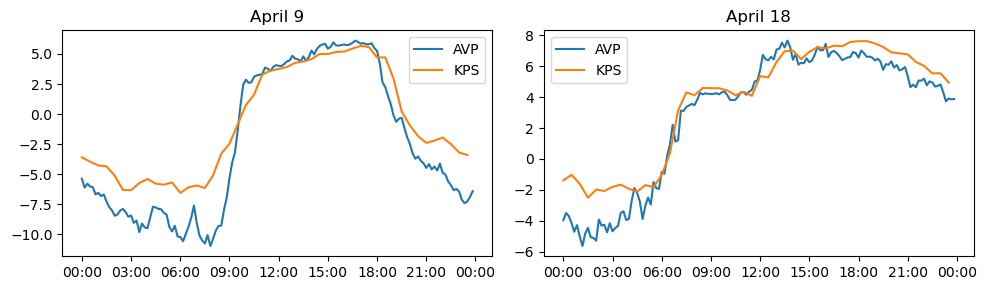

In [64]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter for April 9 and April 18
april9 = '2023-04-09'
april18 = '2023-04-18'

splash_april9 = splash_temps_df.loc[april9]
splash_april18 = splash_temps_df.loc[april18]
sos_april9 = sos_temps_df.loc[april9]
sos_april18 = sos_temps_df.loc[april18]

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=False)

# April 9 subplot
axes[0].plot(splash_april9.index, splash_april9['temp'], label='AVP')
axes[0].plot(sos_april9.index, sos_april9['T_3m_c'], label='KPS')
axes[0].set_title('April 9')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# April 18 subplot
axes[1].plot(splash_april18.index, splash_april18['temp'], label='AVP')
axes[1].plot(sos_april18.index, sos_april18['T_3m_c'], label='KPS')
axes[1].set_title('April 18')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))


plt.tight_layout()
plt.show()

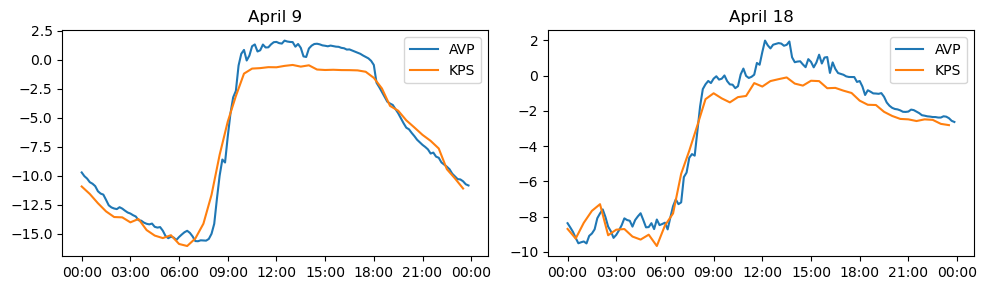

In [65]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter for April 9 and April 18
april9 = '2023-04-09'
april18 = '2023-04-18'

splash_april9 = splash_temps_df.loc[april9]
splash_april18 = splash_temps_df.loc[april18]
sos_april9 = sos_temps_df.loc[april9]
sos_april18 = sos_temps_df.loc[april18]

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=False)

# April 9 subplot
axes[0].plot(splash_april9.index, splash_april9['skin_temp_surface'], label='AVP')
axes[0].plot(sos_april9.index, sos_april9['Tsurf_c'], label='KPS')
axes[0].set_title('April 9')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# April 18 subplot
axes[1].plot(splash_april18.index, splash_april18['skin_temp_surface'], label='AVP')
axes[1].plot(sos_april18.index, sos_april18['Tsurf_c'], label='KPS')
axes[1].set_title('April 18')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))


plt.tight_layout()
plt.show()

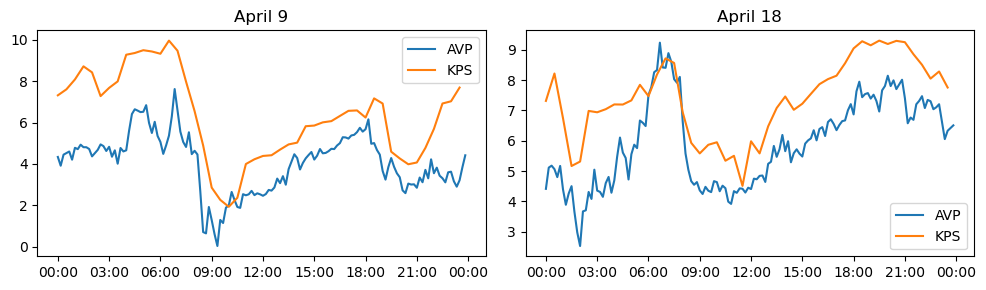

In [66]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter for April 9 and April 18
april9 = '2023-04-09'
april18 = '2023-04-18'

splash_april9 = splash_temps_df.loc[april9]
splash_april18 = splash_temps_df.loc[april18]
sos_april9 = sos_temps_df.loc[april9]
sos_april18 = sos_temps_df.loc[april18]

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=False)

# April 9 subplot
axes[0].plot(splash_april9.index, splash_april9['∆T'], label='AVP')
axes[0].plot(sos_april9.index, sos_april9['∆T'], label='KPS')
axes[0].set_title('April 9')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# April 18 subplot
axes[1].plot(splash_april18.index, splash_april18['∆T'], label='AVP')
axes[1].plot(sos_april18.index, sos_april18['∆T'], label='KPS')
axes[1].set_title('April 18')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))


plt.tight_layout()
plt.show()